# 03 — 生成并可选提交 Boolean QOS 的 OpenQASM 2.0

这一章把单个样本

$$
e^{i\theta_i|x_i\rangle\langle x_i|}
$$

写成明确的门：

```text
X mask → equality flag → phase → uncompute → undo mask
```

第一版只支持 1–2 个地址量子比特。两地址位使用一个工作 ancilla 和
OpenQASM 2.0 的 `ccx`。更大 MCX 必须先决定 ancilla 和分解策略，
不能假装成一个免费原生门。

默认只生成、验证和保存 QASM，不会连接或提交到云端。

In [1]:
import hashlib
import json
import os
from collections import Counter
from getpass import getpass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 20260728

In [2]:
def append_projector_phase_qasm(lines, n_address, address, theta):
    if n_address not in (1, 2):
        raise NotImplementedError(
            "This auditable OpenQASM prototype supports n_address=1 or 2."
        )
    if not 0 <= address < 2**n_address:
        raise ValueError("address is outside the register.")

    work = n_address
    zero_bits = [
        bit
        for bit in range(n_address)
        if ((address >> bit) & 1) == 0
    ]

    for bit in zero_bits:
        lines.append(f"x q[{bit}];")

    if n_address == 1:
        lines.append(f"cx q[0],q[{work}];")
    else:
        lines.append(f"ccx q[0],q[1],q[{work}];")

    lines.append(f"u1({float(theta):.16g}) q[{work}];")

    if n_address == 1:
        lines.append(f"cx q[0],q[{work}];")
    else:
        lines.append(f"ccx q[0],q[1],q[{work}];")

    for bit in reversed(zero_bits):
        lines.append(f"x q[{bit}];")


def build_boolean_qos_verification_qasm(f_values, stream):
    f_values = np.asarray(f_values, dtype=np.int8)
    stream = np.asarray(stream, dtype=int)
    n_states = len(f_values)
    n_address = int(np.log2(n_states))

    if 2**n_address != n_states:
        raise ValueError("f_values length must be a power of two.")
    if n_address not in (1, 2):
        raise NotImplementedError(
            "Hardware QASM prototype currently supports n_address <= 2."
        )
    if len(stream) == 0:
        raise ValueError("stream must not be empty.")
    if np.any((stream < 0) | (stream >= n_states)):
        raise ValueError("stream contains an invalid address.")
    if np.any((f_values != 0) & (f_values != 1)):
        raise ValueError("f_values must be Boolean.")

    n_qubits = n_address + 1
    theta = np.pi * n_states / len(stream)
    lines = [
        "OPENQASM 2.0;",
        'include "qelib1.inc";',
        f"qreg q[{n_qubits}];",
        f"creg c[{n_address}];",
    ]

    for bit in range(n_address):
        lines.append(f"h q[{bit}];")

    # QOS sketch: one sample-dependent update at a time.
    for address in stream:
        if f_values[address] == 1:
            append_projector_phase_qasm(
                lines, n_address, int(address), theta
            )

    # Exact Boolean oracle inverse. For +/-1 phases it is self-inverse.
    for address, value in enumerate(f_values):
        if value == 1:
            append_projector_phase_qasm(
                lines, n_address, address, -np.pi
            )

    for bit in range(n_address):
        lines.append(f"h q[{bit}];")
        lines.append(f"measure q[{bit}] -> c[{bit}];")

    return "\n".join(lines) + "\n"


def expected_plus_fidelity(f_values, stream):
    n_states = len(f_values)
    theta = np.pi * n_states / len(stream)
    counts = np.bincount(stream, minlength=n_states)
    sketch_phase = theta * counts * f_values
    overlap = np.mean(
        np.exp(1j * (sketch_phase - np.pi * f_values))
    )
    return float(abs(overlap) ** 2)


def gate_counts(qasm_text):
    supported = ("h ", "x ", "cx ", "ccx ", "u1(", "measure ")
    counter = Counter()
    for raw_line in qasm_text.splitlines():
        line = raw_line.strip()
        for gate in supported:
            if line.startswith(gate):
                counter[gate.strip(" (")] += 1
                break
    return dict(counter)

## 生成 $n=2$ 的 parity QOS 验证线路

为了把“硬件门误差”和“随机数据流误差”分开，第一条真机 smoke test
使用**平衡但随机打乱顺序**的数据流：每个地址恰好出现 $M/N$ 次。
因此理想 $F_+=1$，真机偏差主要来自编译、门和读出。随机数据流的
sampling scaling 已在 `01`、`02` 中验证；后续真机实验再提交多条随机流。

标签由 `f_values[address]` 当场得到，不需要保存额外标签数组。

In [3]:
n_address = 2
n_states = 2**n_address
f_values = np.array(
    [x.bit_count() % 2 for x in range(n_states)], dtype=np.int8
)
M_DATA = 32
rng = np.random.default_rng(SEED)
if M_DATA % n_states != 0:
    raise ValueError("Balanced smoke-test stream requires M_DATA % N == 0.")
stream = np.tile(np.arange(n_states), M_DATA // n_states)
rng.shuffle(stream)

qasm_text = build_boolean_qos_verification_qasm(f_values, stream)
qasm_hash = hashlib.sha256(qasm_text.encode("utf-8")).hexdigest()
expected_fidelity = expected_plus_fidelity(f_values, stream)

metadata = {
    "experiment": "boolean_qos_plus_state_verification",
    "seed": SEED,
    "n_address": n_address,
    "n_total_qubits": n_address + 1,
    "N": n_states,
    "M_data": M_DATA,
    "stream_mode": "balanced_shuffled_smoke_test",
    "function": "parity",
    "expected_F_plus": expected_fidelity,
    "qasm_sha256": qasm_hash,
    "gate_counts_before_transpile": gate_counts(qasm_text),
}

display(pd.Series(metadata, name="value").to_frame())

,value
experiment,boolean_qos_plus_state_verification
seed,20260728
n_address,2
n_total_qubits,3
N,4
M_data,32
stream_mode,balanced_shuffled_smoke_test
function,parity
expected_F_plus,1.0
qasm_sha256,7a2cfc363092523520da63ced30f693798d25c0c5a6ff3...


## Qiskit 解析与线路可视化

这里显示两张图：

- **概览图**：突出 $H^{\otimes n}\rightarrow\widetilde O_f\rightarrow O_f^\dagger\rightarrow H^{\otimes n}\rightarrow$ 测量；
- **完整图**：逐门显示这条 QASM 中的 X mask、CCX 和相位门。

Qiskit 成功解析并画出线路，是本地语法检查；最终能否在具体 Quafu-SQC 后端编译，
仍必须以真机任务返回结果为准。

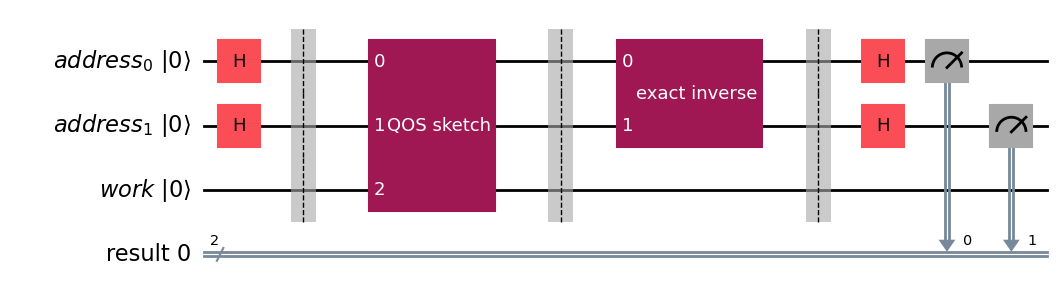

Parsed full QASM operations: OrderedDict({'x': 36, 'ccx': 36, 'u1': 18, 'h': 4, 'measure': 2})


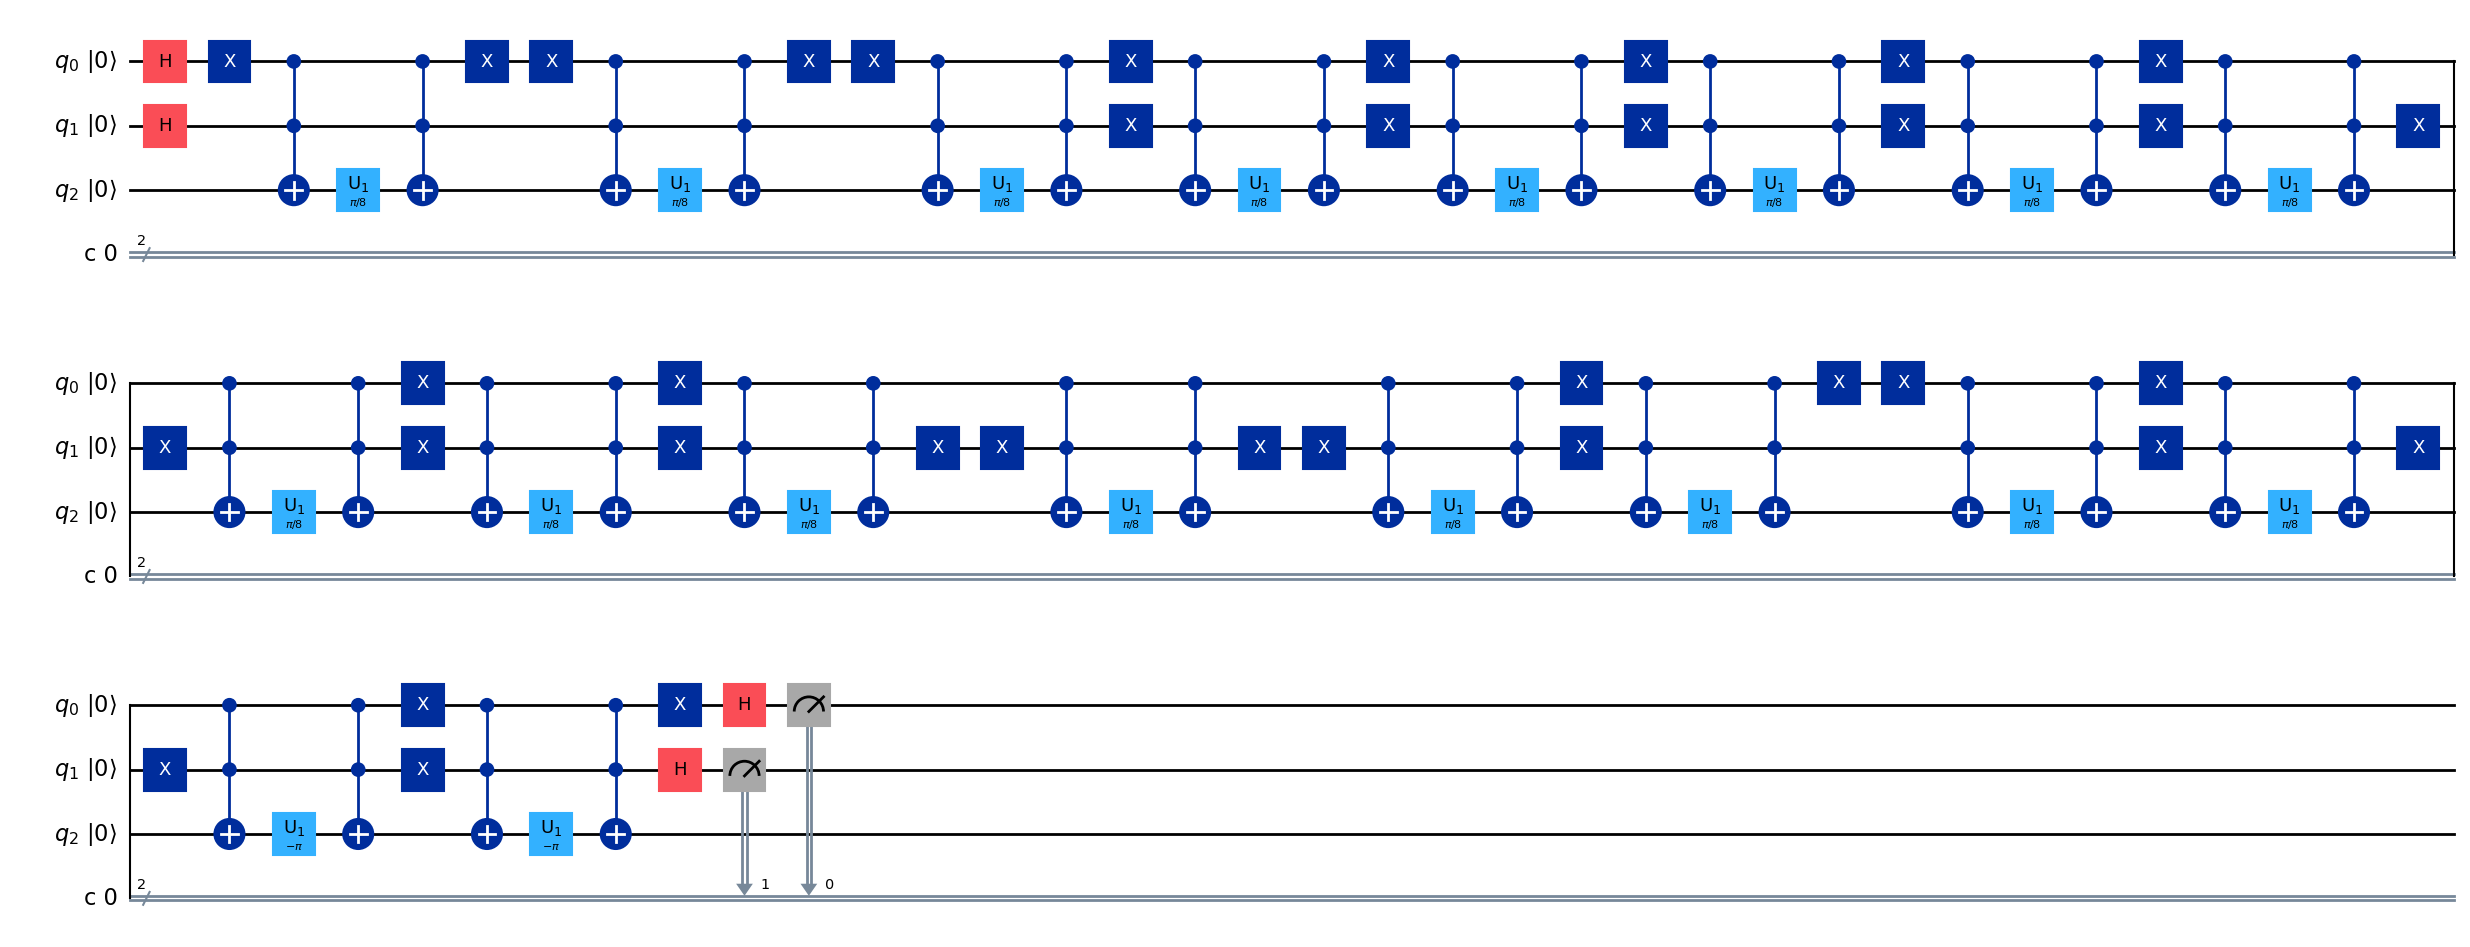

In [4]:
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, qasm2
from qiskit.circuit import Gate

asset_dir = Path("../assets/circuits")
asset_dir.mkdir(parents=True, exist_ok=True)

# 1. 容易阅读的逻辑概览图。
overview_address = QuantumRegister(n_address, "address")
overview_work = QuantumRegister(1, "work")
overview_result = ClassicalRegister(n_address, "result")
overview_circuit = QuantumCircuit(
    overview_address,
    overview_work,
    overview_result,
)
overview_circuit.h(overview_address)
overview_circuit.barrier()
overview_circuit.append(
    Gate("QOS sketch", n_address + 1, []),
    list(overview_address) + list(overview_work),
)
overview_circuit.barrier()
overview_circuit.append(
    Gate("exact inverse", n_address, []),
    list(overview_address),
)
overview_circuit.barrier()
overview_circuit.h(overview_address)
overview_circuit.measure(overview_address, overview_result)

overview_figure = overview_circuit.draw(
    output="mpl",
    fold=-1,
    idle_wires=False,
    initial_state=True,
)
overview_figure.savefig(
    asset_dir / "qos-verification-overview.png",
    dpi=180,
    bbox_inches="tight",
)
display(overview_figure)

# 2. 对真正提交的 QASM 进行独立解析并逐门绘图。
full_qiskit_circuit = qasm2.loads(qasm_text)
print("Parsed full QASM operations:", full_qiskit_circuit.count_ops())
full_figure = full_qiskit_circuit.draw(
    output="mpl",
    fold=36,
    idle_wires=False,
    initial_state=True,
)
full_figure.savefig(
    asset_dir / "qos-full-n2.png",
    dpi=160,
    bbox_inches="tight",
)
display(full_figure)

In [5]:
qasm_lines = qasm_text.splitlines()
preview_lines = 90
print("\n".join(qasm_lines[:preview_lines]))
if len(qasm_lines) > preview_lines:
    print(f"... ({len(qasm_lines) - preview_lines} more lines)")

OPENQASM 2.0;
include "qelib1.inc";
qreg q[3];
creg c[2];
h q[0];
h q[1];
x q[0];
ccx q[0],q[1],q[2];
u1(0.3926990816987241) q[2];
ccx q[0],q[1],q[2];
x q[0];
x q[0];
ccx q[0],q[1],q[2];
u1(0.3926990816987241) q[2];
ccx q[0],q[1],q[2];
x q[0];
x q[0];
ccx q[0],q[1],q[2];
u1(0.3926990816987241) q[2];
ccx q[0],q[1],q[2];
x q[0];
x q[1];
ccx q[0],q[1],q[2];
u1(0.3926990816987241) q[2];
ccx q[0],q[1],q[2];
x q[1];
x q[0];
ccx q[0],q[1],q[2];
u1(0.3926990816987241) q[2];
ccx q[0],q[1],q[2];
x q[0];
x q[1];
ccx q[0],q[1],q[2];
u1(0.3926990816987241) q[2];
ccx q[0],q[1],q[2];
x q[1];
x q[0];
ccx q[0],q[1],q[2];
u1(0.3926990816987241) q[2];
ccx q[0],q[1],q[2];
x q[0];
x q[1];
ccx q[0],q[1],q[2];
u1(0.3926990816987241) q[2];
ccx q[0],q[1],q[2];
x q[1];
x q[1];
ccx q[0],q[1],q[2];
u1(0.3926990816987241) q[2];
ccx q[0],q[1],q[2];
x q[1];
x q[0];
ccx q[0],q[1],q[2];
u1(0.3926990816987241) q[2];
ccx q[0],q[1],q[2];
x q[0];
x q[1];
ccx q[0],q[1],q[2];
u1(0.3926990816987241) q[2];
ccx q[0],q[1],q[2];

## 保存可审计产物

保存的 QASM 不含 token。实际真机运行后，还应保存 `tid`、原始 counts、
`result['transpiled']`、后端名称和运行时间。

In [6]:
results_dir = Path("../results")
results_dir.mkdir(parents=True, exist_ok=True)

qasm_path = results_dir / "boolean_qos_n2.qasm"
metadata_path = results_dir / "boolean_qos_n2_metadata.json"
qasm_path.write_text(qasm_text, encoding="utf-8")
metadata_path.write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("Saved:", qasm_path)
print("Saved:", metadata_path)

Saved: ../results/boolean_qos_n2.qasm
Saved: ../results/boolean_qos_n2_metadata.json


## 准备 Quafu-SQC 任务

当前官方 `quafusqc` API 接收任务字典。远端 compiler 选项不要求本地安装
QuarkStudio。

In [7]:
BACKEND = "Baihua"
S_SHOTS = 1024

task = {
    "chip": BACKEND,
    "name": f"qos_boolean_n{n_address}_M{M_DATA}",
    "circuit": qasm_text,
    "shots": S_SHOTS,
    "compile": True,
    "options": {
        "compiler": "quarkcircuit",
        "correct": False,
        "open_dd": None,
        "target_qubits": [],
    },
}

print("Task prepared; not submitted.")
print(
    {
        "chip": BACKEND,
        "shots": S_SHOTS,
        "name": task["name"],
        "qasm_sha256": qasm_hash,
    }
)

Task prepared; not submitted.
{'chip': 'Baihua', 'shots': 1024, 'name': 'qos_boolean_n2_M32', 'qasm_sha256': '7a2cfc363092523520da63ced30f693798d25c0c5a6ff3408d32132e5a4678d1'}


## 可选：查询后端并提交

凭据只通过环境变量或隐藏输入提供。默认两个开关都是 `False`。

In [8]:
CHECK_BACKENDS = False
SUBMIT_TO_HARDWARE = False
tmgr = None
task_id = None

if CHECK_BACKENDS or SUBMIT_TO_HARDWARE:
    from quafu import Task

    token = os.environ.get("QPU_API_TOKEN") or getpass(
        "请输入新生成的 Quafu-SQC token（输入不会显示）: "
    )
    tmgr = Task(token)
    live_status = tmgr.status()
    print("Live backend status:", live_status)

if SUBMIT_TO_HARDWARE:
    if live_status.get(BACKEND) in {"Offline", "Maintenance"}:
        raise RuntimeError(
            f"{BACKEND} 当前不可用，请选择一个可用且队列合理的后端。"
        )
    task_id = tmgr.run(task)
    print("Submitted task id:", task_id)
else:
    print("Hardware submission disabled.")

Hardware submission disabled.


## 可选：获取已有任务结果

把 `RESULT_TASK_ID` 设置为平台返回的整数。结果是异步的；如果任务还没完成，
请稍后重新运行该单元。

In [9]:
RESULT_TASK_ID = None

if RESULT_TASK_ID is not None:
    if tmgr is None:
        from quafu import Task

        token = os.environ.get("QPU_API_TOKEN") or getpass(
            "请输入新生成的 Quafu-SQC token（输入不会显示）: "
        )
        tmgr = Task(token)

    result = tmgr.result(int(RESULT_TASK_ID), timeout=60)
    print("Status:", result.get("status"))
    if result.get("status") == "Finished":
        counts = result["count"]
        total = sum(counts.values())
        observed_fidelity = counts.get("0" * n_address, 0) / total
        print("Observed F_+:", observed_fidelity)

        fig, ax = plt.subplots(figsize=(6, 4))
        keys = sorted(counts)
        ax.bar(keys, [counts[key] for key in keys])
        ax.set(
            xlabel="Measured bitstring",
            ylabel="Counts",
            title=f"Quafu-SQC Boolean QOS, task {RESULT_TASK_ID}",
        )
        plt.show()
    else:
        print(result)
else:
    print("No task id supplied; result retrieval skipped.")

No task id supplied; result retrieval skipped.


### 真机结果应如何表述

这条静态 QASM 验证的是 `V_M ... V_1` 的门级作用。因为完整线路在上传前
已经包含全部样本门，它不是严格的系统级在线 streaming 演示。

此外 `ccx` 会在远端编译为原生门。必须分析 `result['transpiled']`，
不能只报告逻辑级 `ccx` 数量。